# 03b - Future-Weather Look-Ahead Ablation - 22.03.2026

This notebook is a **feature-engineering extension notebook** that sits between the main feature export work and the later LSTM comparison notebooks.

The question is narrow on purpose:

`How much do future temperature and RH help, and how much of that gain survives forecast uncertainty?`

Why this notebook exists:

- it keeps the future-weather logic compact and inspectable,
- it prototypes the block before anything is copied back into `03_feature_engineering_10032026.ipynb`,
- it separates a small look-ahead feature question from the broader architecture and feature-mode notebooks,
- and it produces paste-ready notes for the thesis experiment chapter.

The comparison is organized as three future-weather modes:

- `FW0`: no future weather,
- `FW1`: oracle future weather,
- `FW2`: forecast-like proxy future weather.

For cumulative targets, the future-weather block is intentionally richer than a single endpoint lookup:

- compact window summaries retain coarse planning-signal information,
- per-hour future temperature and RH preserve the within-window trajectory seen by the model,
- and the richer cumulative block is included because the goal of this notebook is now performance improvement rather than the smallest possible ablation.


In [1]:
from __future__ import annotations

import hashlib
import os
import sys
import types
from dataclasses import dataclass
from pathlib import Path
from textwrap import dedent
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


## Section 1 - Experiment design

This notebook deliberately stays small and asymmetric by task type.

Default setup:

- short direct horizons: `1h, 2h, 3h, 4h, 6h`
- short diagnostic buildings: `U05`, `U06`
- cumulative horizons: `8h, 12h, 16h, 20h, 24h, 36h`
- cumulative main buildings: `U05, U06, LIB, U02B, SOC, U03`
- future-weather variables: `future temperature` and `future RH` only
- backbone: one frozen single-layer LSTM with `72h` lookback

Interpretation intent:

- `FW1 - FW0`: upper-bound value of seeing future weather perfectly,
- `FW2 - FW0`: operational value after forecast uncertainty is introduced,
- `FW1 - FW2`: penalty from forecast error.


In [2]:
PROJECT_ROOT = Path('/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project')
FEATURE_METADATA_FILE = PROJECT_ROOT / 'data' / 'features' / 'feature_metadata.csv'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'future_weather_lookahead_22032026'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SHORT_RUNLOG_FILE = RESULTS_DIR / 'short_run_log.csv'
SHORT_SUMMARY_FILE = RESULTS_DIR / 'short_summary.csv'
CUM_RUNLOG_FILE = RESULTS_DIR / 'cumulative_run_log.csv'
CUM_SUMMARY_FILE = RESULTS_DIR / 'cumulative_summary.csv'
GAIN_FILE = RESULTS_DIR / 'gain_vs_anchor.csv'
CH4_NOTE_FILE = RESULTS_DIR / 'draft_ch4_note.md'
CH6_NOTE_FILE = RESULTS_DIR / 'draft_ch6_note.md'
HORIZON_PLOT_FILE = RESULTS_DIR / 'future_weather_horizon_curve.png'
TRACE_PLOT_FILE = RESULTS_DIR / 'future_weather_trace_u05_cum24.png'

DEFAULT_TARGET_SOURCE_COL = 'heat_kwh'
HEATING_TEMP_THRESHOLD_C = 15.0
HEATING_MONTHS = [1, 2, 3, 11, 12]
SHORT_HORIZONS = [1, 2, 3, 4, 6]
CUMULATIVE_HORIZONS = [8, 12, 16, 20, 24, 36]
SHORT_BUILDINGS = ['U05', 'U06']
CUMULATIVE_BUILDINGS = ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']

PRIMARY_METRIC = 'wape_heating_pct'
SEED = 42
EPOCHS = 18
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 4
FIT_VALIDATION_FRACTION = 0.10
MAX_TRAIN_SEQUENCES = 25000

POINT_ANCHOR_FEATURES = [
    'feat_heat_obs',
    'feat_outdoor_temp_c',
    'feat_rh_pct',
    'feat_wind_ms',
    'feat_solar_irradiance_wm2',
    'feat_hour_sin',
    'feat_hour_cos',
    'feat_dow_sin',
    'feat_dow_cos',
    'feat_is_weekend',
    'feat_heat_lag1',
    'feat_heat_lag3',
    'feat_heat_lag24',
    'feat_heat_lag168',
    'feat_heat_roll6h',
    'feat_heat_roll24h',
]

CUMULATIVE_ANCHOR_FEATURES = POINT_ANCHOR_FEATURES + [
    'feat_hdh_15c',
    'feat_temp_roll24h',
    'feat_space_heat_active',
    'feat_space_deltaT_c',
    'feat_space_deltaT_roll24h',
    'feat_space_low_deltaT_flag',
    'feat_vent_heat_active',
    'feat_vent_deltaT_c',
    'feat_vent_deltaT_roll24h',
    'feat_vent_low_deltaT_flag',
]

FUTURE_WEATHER_MODES = ['FW0', 'FW1', 'FW2']


@dataclass(frozen=True)
class FrozenArchitecture:
    key: str
    label: str
    lookback_hours: int
    lstm_units: tuple[int, ...]
    dropout: float
    dense_units: int


ARCHITECTURE = FrozenArchitecture(
    key='single_64_l72',
    label='single 64 | L72',
    lookback_hours=72,
    lstm_units=(64,),
    dropout=0.0,
    dense_units=16,
)


@dataclass(frozen=True)
class MonthlyFold:
    fold_id: str
    train_end: pd.Timestamp
    test_start: pd.Timestamp
    test_end: pd.Timestamp


def build_monthly_folds(year: int = 2024, months: list[int] | None = None) -> list[MonthlyFold]:
    months = months or HEATING_MONTHS
    folds: list[MonthlyFold] = []
    for month in months:
        test_start = pd.Timestamp(year=year, month=int(month), day=1, hour=0)
        test_end = (test_start + pd.offsets.MonthEnd(1)).replace(hour=23)
        train_end = test_start - pd.Timedelta(hours=1)
        folds.append(MonthlyFold(
            fold_id=f'{test_start:%Y-%m}',
            train_end=train_end,
            test_start=test_start,
            test_end=test_end,
        ))
    return folds


FOLDS = build_monthly_folds()
print('Results directory  :', RESULTS_DIR)
print('Architecture       :', ARCHITECTURE.label)
print('Short horizons     :', SHORT_HORIZONS)
print('Cumulative horizons:', CUMULATIVE_HORIZONS)


Results directory  : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/future_weather_lookahead_22032026
Architecture       : single 64 | L72
Short horizons     : [1, 2, 3, 4, 6]
Cumulative horizons: [8, 12, 16, 20, 24, 36]


## Section 2 - Literature-backed policy

The feature family is intentionally small because this is an **auxiliary availability study**, not a new thesis branch.

Method basis used here:

- `WANG2020114683`: forecasted temperature and relative humidity are operationally relevant, and forecast uncertainty should be treated explicitly.
- `RUNGE2023126661`: actual weather forecasts are a realistic input source for longer-horizon heat-demand forecasting.
- `NEUBAUER2025100480`: future weather inputs can materially affect accuracy in multi-step heating-load forecasting.

Design rule for this notebook:

- short point targets get **endpoint future weather**,
- cumulative targets get **window summaries plus the full per-hour future weather path**,
- proxy weather is generated at run time from training-only uncertainty estimates.


In [3]:
literature_policy = pd.DataFrame([
    {
        'source_key': 'WANG2020114683',
        'used_here_for': 'Future temperature + RH, plus explicit forecast-uncertainty handling',
    },
    {
        'source_key': 'RUNGE2023126661',
        'used_here_for': 'Operational realism of forecast weather in longer-horizon heat-demand work',
    },
    {
        'source_key': 'NEUBAUER2025100480',
        'used_here_for': 'Future weather as a meaningful look-ahead input family',
    },
])
display(literature_policy)


,source_key,used_here_for
0,WANG2020114683,"Future temperature + RH, plus explicit forecas..."
1,RUNGE2023126661,Operational realism of forecast weather in lon...
2,NEUBAUER2025100480,Future weather as a meaningful look-ahead inpu...


## Section 3 - Feature construction

The oracle future-weather block is built **in memory** from the current `setA` exports. That keeps the prototype local to this notebook until the feature logic is judged stable enough to copy back into `03_feature_engineering_10032026.ipynb`.

The cumulative side now carries both compact summaries and stepwise future weather. This matches the target definition more closely: a cumulative `h`-hour target depends on the weather trajectory across hours `1..h`, not only on one endpoint or one pooled summary statistic.


In [4]:
def stable_seed(*parts: object) -> int:
    joined = '::'.join(str(p) for p in parts)
    return int(hashlib.md5(joined.encode('utf-8')).hexdigest()[:8], 16)


def htag(horizon_hours: int) -> str:
    return f'h{int(horizon_hours):02d}'


def load_feature_metadata() -> pd.DataFrame:
    return pd.read_csv(FEATURE_METADATA_FILE)


def feature_path_for_building(building: str) -> Path:
    meta = load_feature_metadata()
    row = meta.loc[meta['building'] == building]
    if row.empty:
        raise KeyError(f'Building {building} not found in feature metadata')
    rel = row.iloc[0]['path_setA']
    return (PROJECT_ROOT / str(rel)).resolve()


def load_feature_frame(building: str) -> pd.DataFrame:
    path = feature_path_for_building(building)
    df = pd.read_csv(path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    return df.sort_values('datetime').reset_index(drop=True)


def build_future_summary_columns(series: pd.Series, horizon_hours: int) -> tuple[pd.Series, pd.Series, pd.Series]:
    future_mat = pd.concat([series.shift(-k) for k in range(1, int(horizon_hours) + 1)], axis=1)
    mean_col = future_mat.mean(axis=1)
    min_col = future_mat.min(axis=1)
    end_col = series.shift(-int(horizon_hours))
    return mean_col, min_col, end_col


def build_future_path_columns(series: pd.Series, horizon_hours: int, prefix: str) -> dict[str, pd.Series]:
    tag = htag(horizon_hours)
    cols: dict[str, pd.Series] = {}
    for step in range(1, int(horizon_hours) + 1):
        cols[f'{prefix}_tplus{step:02d}_{tag}'] = series.shift(-step)
    return cols


def add_oracle_future_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for h in SHORT_HORIZONS:
        tag = htag(h)
        out[f'feat_fw_temp_end_{tag}'] = out['feat_outdoor_temp_c'].shift(-int(h))
        out[f'feat_fw_rh_end_{tag}'] = out['feat_rh_pct'].shift(-int(h))
    for h in CUMULATIVE_HORIZONS:
        tag = htag(h)
        temp_mean, temp_min, temp_end = build_future_summary_columns(out['feat_outdoor_temp_c'], h)
        rh_mean, _, _ = build_future_summary_columns(out['feat_rh_pct'], h)
        out[f'feat_fw_temp_mean_{tag}'] = temp_mean
        out[f'feat_fw_temp_min_{tag}'] = temp_min
        out[f'feat_fw_temp_end_{tag}'] = temp_end
        out[f'feat_fw_rh_mean_{tag}'] = rh_mean
        for col_name, values in build_future_path_columns(out['feat_outdoor_temp_c'], h, 'feat_fw_temp').items():
            out[col_name] = values
        for col_name, values in build_future_path_columns(out['feat_rh_pct'], h, 'feat_fw_rh').items():
            out[col_name] = values
    return out


def future_weather_feature_cols(task_kind: str, horizon_hours: int) -> list[str]:
    tag = htag(horizon_hours)
    if task_kind == 'point':
        return [
            f'feat_fw_temp_end_{tag}',
            f'feat_fw_rh_end_{tag}',
        ]
    if task_kind == 'cumulative':
        cols = [
            f'feat_fw_temp_mean_{tag}',
            f'feat_fw_temp_min_{tag}',
            f'feat_fw_temp_end_{tag}',
            f'feat_fw_rh_mean_{tag}',
        ]
        for step in range(1, int(horizon_hours) + 1):
            cols.append(f'feat_fw_temp_tplus{step:02d}_{tag}')
            cols.append(f'feat_fw_rh_tplus{step:02d}_{tag}')
        return cols
    raise ValueError(f'Unknown task kind: {task_kind}')


def base_feature_cols(task_kind: str) -> list[str]:
    if task_kind == 'point':
        return list(POINT_ANCHOR_FEATURES)
    if task_kind == 'cumulative':
        return list(CUMULATIVE_ANCHOR_FEATURES)
    raise ValueError(f'Unknown task kind: {task_kind}')


def variant_feature_cols(task_kind: str, horizon_hours: int, fw_mode: str) -> list[str]:
    cols = list(base_feature_cols(task_kind))
    if fw_mode in {'FW1', 'FW2'}:
        cols.extend(future_weather_feature_cols(task_kind, horizon_hours))
    return list(dict.fromkeys(cols))


sample_df = add_oracle_future_weather_features(load_feature_frame('U05'))
sample_future_cols = [c for c in sample_df.columns if c.startswith('feat_fw_')][:12]
print('Sample future-weather columns:')
print(sample_future_cols)


Sample future-weather columns:
['feat_fw_temp_end_h01', 'feat_fw_rh_end_h01', 'feat_fw_temp_end_h02', 'feat_fw_rh_end_h02', 'feat_fw_temp_end_h03', 'feat_fw_rh_end_h03', 'feat_fw_temp_end_h04', 'feat_fw_rh_end_h04', 'feat_fw_temp_end_h06', 'feat_fw_rh_end_h06', 'feat_fw_temp_mean_h08', 'feat_fw_temp_min_h08']


/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

## Section 4 - Proxy calibration

`FW2` is created at run time from the oracle columns. The uncertainty scale is estimated only from the training segment, using a same-hour-previous-day seasonal-persistence baseline.

This keeps the proxy simple, local, and non-leaky.


In [5]:
def add_prevday_baseline_future_features(df: pd.DataFrame) -> pd.DataFrame:
    shifted = df.copy()
    shifted['feat_outdoor_temp_c'] = shifted['feat_outdoor_temp_c'].shift(24)
    shifted['feat_rh_pct'] = shifted['feat_rh_pct'].shift(24)
    return add_oracle_future_weather_features(shifted)


def calibrate_proxy_sigmas(df: pd.DataFrame, used_future_cols: list[str], train_issue_mask: np.ndarray) -> dict[str, float]:
    baseline_df = add_prevday_baseline_future_features(df)
    sigmas: dict[str, float] = {}
    for col in used_future_cols:
        resid = (df[col] - baseline_df[col]).to_numpy(dtype='float64')
        train_resid = resid[train_issue_mask & np.isfinite(resid)]
        if len(train_resid) >= 5:
            sigma = float(np.nanstd(train_resid, ddof=1))
        else:
            sigma = 0.0
        if not np.isfinite(sigma):
            sigma = 0.0
        sigmas[col] = sigma
    return sigmas


def apply_proxy_future_weather(
    df: pd.DataFrame,
    used_future_cols: list[str],
    train_issue_mask: np.ndarray,
    building: str,
    task_kind: str,
    horizon_hours: int,
    fold_id: str,
) -> pd.DataFrame:
    out = df.copy()
    sigmas = calibrate_proxy_sigmas(out, used_future_cols=used_future_cols, train_issue_mask=train_issue_mask)
    for col in used_future_cols:
        sigma = float(sigmas.get(col, 0.0))
        seed = stable_seed(SEED, building, task_kind, horizon_hours, fold_id, col)
        rng = np.random.default_rng(seed)
        noise = rng.normal(loc=0.0, scale=sigma, size=len(out))
        out[col] = out[col].astype(float) + noise
        if 'rh_' in col:
            out[col] = out[col].clip(0.0, 100.0)
    return out


## Section 5 - Run helpers

The backbone is kept frozen so the notebook answers a feature-availability question rather than reopening architecture search.


In [6]:
def install_cv2_stub() -> None:
    module = sys.modules.get('cv2')
    if module is None:
        module = types.ModuleType('cv2')
        module.dnn = types.SimpleNamespace(DictValue=object)
        sys.modules['cv2'] = module
        return
    if not hasattr(module, 'dnn'):
        module.dnn = types.SimpleNamespace(DictValue=object)
        return
    if not hasattr(module.dnn, 'DictValue'):
        module.dnn.DictValue = object


def import_tf():
    os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
    os.environ.setdefault('MPLCONFIGDIR', '/tmp/codex-mplconfig')
    os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
    install_cv2_stub()
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.get_logger().setLevel('ERROR')
    try:
        tf.random.set_seed(SEED)
    except Exception:
        pass
    return tf, keras, layers


def build_lstm_model(n_features: int, architecture: FrozenArchitecture = ARCHITECTURE):
    _, keras, layers = import_tf()
    temporal_in = keras.Input(shape=(architecture.lookback_hours, n_features), name='temporal_input')
    x = temporal_in
    for idx, units in enumerate(architecture.lstm_units):
        return_sequences = idx < len(architecture.lstm_units) - 1
        x = layers.LSTM(units, return_sequences=return_sequences, name=f'lstm_{idx + 1}')(x)
        if return_sequences and architecture.dropout > 0:
            x = layers.Dropout(architecture.dropout, name=f'dropout_{idx + 1}')(x)
    x = layers.Dense(architecture.dense_units, activation='relu', name='dense_1')(x)
    out = layers.Dense(1, name='output')(x)
    try:
        optimizer = keras.optimizers.legacy.Adam(learning_rate=1e-3)
    except Exception:
        optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    model = keras.Model(inputs=temporal_in, outputs=out, name=architecture.key)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])
    return model


def add_direct_target(df: pd.DataFrame, horizon_hours: int, source_col: str = DEFAULT_TARGET_SOURCE_COL) -> tuple[pd.DataFrame, str]:
    out = df.copy()
    target_col = f'target_point_{htag(horizon_hours)}'
    out[target_col] = out[source_col].shift(-int(horizon_hours))
    return out, target_col


def add_cumulative_target(df: pd.DataFrame, horizon_hours: int, source_col: str = DEFAULT_TARGET_SOURCE_COL) -> tuple[pd.DataFrame, str]:
    out = df.copy()
    target_col = f'target_cum_{htag(horizon_hours)}'
    out[target_col] = sum(out[source_col].shift(-i) for i in range(int(horizon_hours)))
    return out, target_col


def heating_mask(df: pd.DataFrame) -> pd.Series:
    if 'feat_is_heating_weather' in df.columns:
        return df['feat_is_heating_weather'].fillna(0).astype(float) > 0.5
    return df['feat_outdoor_temp_c'].astype(float) < HEATING_TEMP_THRESHOLD_C


def issue_train_end_for(task_kind: str, fold: MonthlyFold, horizon_hours: int) -> pd.Timestamp:
    if task_kind == 'point':
        return fold.train_end - pd.Timedelta(hours=int(horizon_hours))
    return fold.train_end - pd.Timedelta(hours=int(horizon_hours) - 1)


def issue_test_end_for(task_kind: str, fold: MonthlyFold, horizon_hours: int) -> pd.Timestamp:
    if task_kind == 'point':
        return fold.test_end - pd.Timedelta(hours=int(horizon_hours))
    return fold.test_end - pd.Timedelta(hours=int(horizon_hours) - 1)


def prepare_scaled_arrays(df: pd.DataFrame, feature_cols: list[str], target_col: str, train_end: pd.Timestamp, issue_train_end: pd.Timestamp):
    dt = pd.to_datetime(df['datetime'])
    imputer = SimpleImputer(strategy='median')
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    fit_x = df.loc[dt <= train_end, feature_cols]
    fit_y = df.loc[(dt <= issue_train_end) & df[target_col].notna(), [target_col]]
    if fit_x.empty or fit_y.empty:
        raise ValueError('No train rows available for feature or target scaling')

    scaler_x.fit(imputer.fit_transform(fit_x))
    scaler_y.fit(fit_y.values)

    X_all = scaler_x.transform(imputer.transform(df[feature_cols]))
    y_all = np.full(len(df), np.nan, dtype='float32')
    valid_y = df[target_col].notna()
    if valid_y.any():
        y_all[valid_y.to_numpy()] = scaler_y.transform(df.loc[valid_y, [target_col]].values)[:, 0]

    return X_all, y_all, scaler_y, dt.to_numpy()


def build_sequences(features, target_scaled, timestamps, heating_flags, issue_mask, lookback, max_sequences=None):
    X_list, y_list, ts_list, heat_list = [], [], [], []
    for end_idx in range(lookback, len(features)):
        if not issue_mask[end_idx]:
            continue
        target_val = target_scaled[end_idx]
        if np.isnan(target_val):
            continue
        window = features[end_idx - lookback:end_idx]
        if np.isnan(window).any():
            continue
        X_list.append(window.astype('float32'))
        y_list.append(float(target_val))
        ts_list.append(np.datetime64(pd.Timestamp(timestamps[end_idx])))
        heat_list.append(bool(heating_flags[end_idx]))
    if not X_list:
        return (
            np.empty((0, lookback, features.shape[1]), dtype='float32'),
            np.empty((0,), dtype='float32'),
            np.empty((0,), dtype='datetime64[ns]'),
            np.empty((0,), dtype=bool),
        )
    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype='float32')
    ts = np.array(ts_list, dtype='datetime64[ns]')
    heat = np.array(heat_list, dtype=bool)
    if max_sequences and len(X) > max_sequences:
        X = X[-max_sequences:]
        y = y[-max_sequences:]
        ts = ts[-max_sequences:]
        heat = heat[-max_sequences:]
    return X, y, ts, heat


def split_train_validation(X, y, heat_flags, frac=FIT_VALIDATION_FRACTION):
    if len(X) < 2 or frac <= 0:
        empty_x = np.empty((0,) + X.shape[1:], dtype=X.dtype)
        empty_y = np.empty((0,), dtype=y.dtype)
        empty_h = np.empty((0,), dtype=bool)
        return X, y, heat_flags, empty_x, empty_y, empty_h
    n_val = max(1, int(round(len(X) * frac)))
    n_val = min(n_val, len(X) - 1)
    split_at = len(X) - n_val
    return (
        X[:split_at], y[:split_at], heat_flags[:split_at],
        X[split_at:], y[split_at:], heat_flags[split_at:]
    )


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    if len(y_true) == 0:
        return {'mae': np.nan, 'rmse': np.nan, 'wape_pct': np.nan, 'r2': np.nan}
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = float(np.sum(np.abs(y_true)))
    wape = float(100.0 * np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    return {'mae': mae, 'rmse': rmse, 'wape_pct': wape, 'r2': r2}


FRAME_CACHE: dict[str, pd.DataFrame] = {}


def prepared_frame_for_building(building: str) -> pd.DataFrame:
    if building not in FRAME_CACHE:
        FRAME_CACHE[building] = add_oracle_future_weather_features(load_feature_frame(building))
    return FRAME_CACHE[building].copy()


def run_single_case(
    building: str,
    task_kind: str,
    horizon_hours: int,
    fw_mode: str,
    fold: MonthlyFold,
    epochs: int = EPOCHS,
    return_predictions: bool = False,
):
    feature_cols = variant_feature_cols(task_kind, horizon_hours, fw_mode)
    df = prepared_frame_for_building(building)
    if task_kind == 'point':
        work_df, target_col = add_direct_target(df, horizon_hours=horizon_hours)
    else:
        work_df, target_col = add_cumulative_target(df, horizon_hours=horizon_hours)
    dt = pd.to_datetime(work_df['datetime'])
    issue_train_end = issue_train_end_for(task_kind, fold, horizon_hours)
    issue_test_end = issue_test_end_for(task_kind, fold, horizon_hours)
    train_issue_mask = (dt <= issue_train_end).to_numpy(dtype=bool)
    test_issue_mask = ((dt >= fold.test_start) & (dt <= issue_test_end)).to_numpy(dtype=bool)
    if fw_mode == 'FW2':
        future_cols = future_weather_feature_cols(task_kind, horizon_hours)
        work_df = apply_proxy_future_weather(
            work_df,
            used_future_cols=future_cols,
            train_issue_mask=train_issue_mask,
            building=building,
            task_kind=task_kind,
            horizon_hours=horizon_hours,
            fold_id=fold.fold_id,
        )
    heat_flags = heating_mask(work_df).to_numpy(dtype=bool)
    X_all, y_all, scaler_y, timestamps = prepare_scaled_arrays(
        work_df,
        feature_cols=feature_cols,
        target_col=target_col,
        train_end=fold.train_end,
        issue_train_end=issue_train_end,
    )
    X_train, y_train, _, train_heat = build_sequences(
        X_all, y_all, timestamps, heat_flags, train_issue_mask,
        lookback=ARCHITECTURE.lookback_hours,
        max_sequences=MAX_TRAIN_SEQUENCES,
    )
    X_test, y_test, test_ts, test_heat = build_sequences(
        X_all, y_all, timestamps, heat_flags, test_issue_mask,
        lookback=ARCHITECTURE.lookback_hours,
    )
    if len(X_train) == 0 or len(X_test) == 0:
        row = {
            'status': 'no_data',
            'building': building,
            'task_kind': task_kind,
            'horizon_hours': int(horizon_hours),
            'fw_mode': fw_mode,
            'target_col': target_col,
            'fold_id': fold.fold_id,
            'feature_cols': ','.join(feature_cols),
            'train_seq': int(len(X_train)),
            'test_seq': int(len(X_test)),
        }
        return row if not return_predictions else (row, pd.DataFrame())
    X_fit, y_fit, _, X_val, y_val, _ = split_train_validation(X_train, y_train, train_heat)
    model = build_lstm_model(len(feature_cols))
    callbacks = []
    _, keras, _ = import_tf()
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True))
    start = perf_counter()
    history = model.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val) if len(X_val) else None,
        epochs=int(epochs),
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
        shuffle=False,
    )
    elapsed_s = perf_counter() - start
    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1)
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))[:, 0]
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))[:, 0]
    overall = compute_metrics(y_true, y_pred)
    heating = compute_metrics(y_true[test_heat], y_pred[test_heat])
    row = {
        'status': 'ok',
        'building': building,
        'task_kind': task_kind,
        'horizon_hours': int(horizon_hours),
        'fw_mode': fw_mode,
        'target_col': target_col,
        'fold_id': fold.fold_id,
        'feature_cols': ','.join(feature_cols),
        'train_seq': int(len(X_train)),
        'test_seq': int(len(X_test)),
        'epochs_trained': int(len(history.history.get('loss', []))),
        'elapsed_s': float(elapsed_s),
        'mae_all': overall['mae'],
        'rmse_all': overall['rmse'],
        'wape_all_pct': overall['wape_pct'],
        'r2_all': overall['r2'],
        'mae_heating': heating['mae'],
        'rmse_heating': heating['rmse'],
        'wape_heating_pct': heating['wape_pct'],
        'r2_heating': heating['r2'],
    }
    pred_df = pd.DataFrame({
        'datetime': pd.to_datetime(test_ts),
        'y_true': y_true,
        'y_pred': y_pred,
        'is_heating': test_heat,
        'building': building,
        'task_kind': task_kind,
        'horizon_hours': int(horizon_hours),
        'fw_mode': fw_mode,
        'fold_id': fold.fold_id,
    })
    return row if not return_predictions else (row, pred_df)


In [7]:
def summarize_run_log(run_log: pd.DataFrame) -> pd.DataFrame:
    if run_log is None or run_log.empty:
        return pd.DataFrame()
    ok = run_log.loc[run_log['status'] == 'ok'].copy()
    if ok.empty:
        return pd.DataFrame()
    summary = (
        ok.groupby(['task_kind', 'building', 'horizon_hours', 'fw_mode'], as_index=False)
          .agg(
              n_folds=('fold_id', 'nunique'),
              mean_wape_heating_pct=('wape_heating_pct', 'mean'),
              mean_rmse_heating=('rmse_heating', 'mean'),
              mean_r2_heating=('r2_heating', 'mean'),
              mean_wape_all_pct=('wape_all_pct', 'mean'),
              mean_elapsed_s=('elapsed_s', 'mean'),
          )
          .sort_values(['building', 'horizon_hours', 'fw_mode'])
          .reset_index(drop=True)
    )
    return summary


def overall_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    overall = (
        summary_df.groupby(['task_kind', 'horizon_hours', 'fw_mode'], as_index=False)
                 .agg(
                     n_buildings=('building', 'nunique'),
                     mean_wape_heating_pct=('mean_wape_heating_pct', 'mean'),
                     mean_rmse_heating=('mean_rmse_heating', 'mean'),
                     mean_r2_heating=('mean_r2_heating', 'mean'),
                 )
                 .sort_values(['task_kind', 'horizon_hours', 'fw_mode'])
                 .reset_index(drop=True)
    )
    return overall


def gain_vs_fw0(summary_df: pd.DataFrame) -> pd.DataFrame:
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    base = summary_df.loc[summary_df['fw_mode'] == 'FW0', ['task_kind', 'building', 'horizon_hours', 'mean_wape_heating_pct']].rename(columns={'mean_wape_heating_pct': 'fw0_wape_heating_pct'})
    merged = summary_df.merge(base, on=['task_kind', 'building', 'horizon_hours'], how='left')
    merged['delta_vs_fw0_wape_pct_points'] = merged['mean_wape_heating_pct'] - merged['fw0_wape_heating_pct']
    return merged.sort_values(['task_kind', 'building', 'horizon_hours', 'fw_mode']).reset_index(drop=True)


def run_suite(
    *,
    task_kind: str,
    buildings: list[str],
    horizons: list[int],
    run_log_path: Path,
    summary_path: Path,
    epochs: int = EPOCHS,
    resume: bool = True,
    max_runs: int | None = None,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict[str, object]] = []
    completed_keys: set[tuple[str, int, str, str]] = set()
    if resume and run_log_path.exists():
        existing = pd.read_csv(run_log_path)
        if not existing.empty:
            rows = existing.to_dict(orient='records')
            completed_ok = existing.loc[existing['status'] == 'ok', ['building', 'horizon_hours', 'fw_mode', 'fold_id']]
            completed_keys = set(map(tuple, completed_ok.to_records(index=False).tolist()))
            if verbose:
                total = len(buildings) * len(horizons) * len(FUTURE_WEATHER_MODES) * len(FOLDS)
                print(f'Resuming from {run_log_path.name}: {len(completed_keys)}/{total} completed')
    done = 0
    for building in buildings:
        for horizon in horizons:
            for fw_mode in FUTURE_WEATHER_MODES:
                for fold in FOLDS:
                    key = (building, int(horizon), fw_mode, fold.fold_id)
                    if key in completed_keys:
                        continue
                    if max_runs is not None and done >= int(max_runs):
                        run_log = pd.DataFrame(rows)
                        summary = summarize_run_log(run_log)
                        run_log.to_csv(run_log_path, index=False)
                        summary.to_csv(summary_path, index=False)
                        return run_log, summary
                    result = run_single_case(
                        building=building,
                        task_kind=task_kind,
                        horizon_hours=int(horizon),
                        fw_mode=fw_mode,
                        fold=fold,
                        epochs=epochs,
                    )
                    rows.append(result)
                    done += 1
                    if verbose:
                        metric = result.get('wape_heating_pct', np.nan)
                        print(f'[{done:>3}] {task_kind:10s} | {building} | h={horizon:>2} | {fw_mode} | {fold.fold_id} | {result["status"]} | wape_heat={metric:.3f}')
                    pd.DataFrame(rows).to_csv(run_log_path, index=False)
    run_log = pd.DataFrame(rows)
    summary = summarize_run_log(run_log)
    run_log.to_csv(run_log_path, index=False)
    summary.to_csv(summary_path, index=False)
    return run_log, summary


## Section 6 - Short-horizon diagnostic

The short-horizon side is intentionally small. It exists to show whether future weather already matters at `1h` to `6h`, but it is not the thesis-facing main experiment.


In [8]:
RUN_SHORT_NOW = True
SHORT_MAX_RUNS = None
SHORT_EPOCHS = EPOCHS

if RUN_SHORT_NOW:
    short_run_log, short_summary = run_suite(
        task_kind='point',
        buildings=SHORT_BUILDINGS,
        horizons=SHORT_HORIZONS,
        run_log_path=SHORT_RUNLOG_FILE,
        summary_path=SHORT_SUMMARY_FILE,
        epochs=SHORT_EPOCHS,
        resume=True,
        max_runs=SHORT_MAX_RUNS,
        verbose=True,
    )
    display(short_summary)
else:
    print('Short run is configured but not started. Set RUN_SHORT_NOW = True to execute it.')


Resuming from short_run_log.csv: 150/150 completed


,task_kind,building,horizon_hours,fw_mode,n_folds,mean_wape_heating_pct,mean_rmse_heating,mean_r2_heating,mean_wape_all_pct,mean_elapsed_s
0,point,U05,1,FW0,5,22.166360,26.508556,0.698831,22.203503,51.790129
1,point,U05,1,FW1,5,20.165811,23.629635,0.759428,20.186176,70.796185
2,point,U05,1,FW2,5,24.131460,27.520371,0.674750,24.158639,56.625007
3,point,U05,2,FW0,5,25.982111,31.169125,0.589072,26.010959,43.494987
4,point,U05,2,FW1,5,25.760883,29.901858,0.623194,25.783783,57.767834
5,point,U05,2,FW2,5,26.739466,31.929686,0.563704,26.770076,46.146860
6,point,U05,3,FW0,5,28.997986,34.757129,0.488195,29.024364,45.378082
7,point,U05,3,FW1,5,28.476508,32.741429,0.547347,28.497532,49.116895
8,point,U05,3,FW2,5,26.082932,31.377150,0.566743,26.103061,50.778117
9,point,U05,4,FW0,5,30.637406,37.024523,0.414760,30.672889,52.580956


## Section 7 - Cumulative main run

This is the thesis-facing part of the notebook. The comparison stays focused on the six-building long-horizon subset already used in the later LSTM work.


In [9]:
RUN_CUMULATIVE_NOW = True
CUMULATIVE_MAX_RUNS = None
CUMULATIVE_EPOCHS = EPOCHS

if RUN_CUMULATIVE_NOW:
    cumulative_run_log, cumulative_summary = run_suite(
        task_kind='cumulative',
        buildings=CUMULATIVE_BUILDINGS,
        horizons=CUMULATIVE_HORIZONS,
        run_log_path=CUM_RUNLOG_FILE,
        summary_path=CUM_SUMMARY_FILE,
        epochs=CUMULATIVE_EPOCHS,
        resume=True,
        max_runs=CUMULATIVE_MAX_RUNS,
        verbose=True,
    )
    display(cumulative_summary)
else:
    print('Cumulative run is configured but not started. Set RUN_CUMULATIVE_NOW = True to execute it.')


Resuming from cumulative_run_log.csv: 441/540 completed


/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

[  1] cumulative | SOC | h=36 | FW1 | 2024-02 | ok | wape_heat=13.831
[  2] cumulative | SOC | h=36 | FW1 | 2024-03 | ok | wape_heat=17.197
[  3] cumulative | SOC | h=36 | FW1 | 2024-11 | ok | wape_heat=15.575
[  4] cumulative | SOC | h=36 | FW1 | 2024-12 | ok | wape_heat=19.848
[  5] cumulative | SOC | h=36 | FW2 | 2024-01 | ok | wape_heat=27.637
[  6] cumulative | SOC | h=36 | FW2 | 2024-02 | ok | wape_heat=11.104
[  7] cumulative | SOC | h=36 | FW2 | 2024-03 | ok | wape_heat=15.693
[  8] cumulative | SOC | h=36 | FW2 | 2024-11 | ok | wape_heat=13.916
[  9] cumulative | SOC | h=36 | FW2 | 2024-12 | ok | wape_heat=19.431


/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

[ 10] cumulative | U03 | h= 8 | FW0 | 2024-01 | ok | wape_heat=16.176
[ 11] cumulative | U03 | h= 8 | FW0 | 2024-02 | ok | wape_heat=6.641
[ 12] cumulative | U03 | h= 8 | FW0 | 2024-03 | ok | wape_heat=18.592
[ 13] cumulative | U03 | h= 8 | FW0 | 2024-11 | ok | wape_heat=26.783
[ 14] cumulative | U03 | h= 8 | FW0 | 2024-12 | ok | wape_heat=13.838
[ 15] cumulative | U03 | h= 8 | FW1 | 2024-01 | ok | wape_heat=11.902
[ 16] cumulative | U03 | h= 8 | FW1 | 2024-02 | ok | wape_heat=8.910
[ 17] cumulative | U03 | h= 8 | FW1 | 2024-03 | ok | wape_heat=16.598
[ 18] cumulative | U03 | h= 8 | FW1 | 2024-11 | ok | wape_heat=26.066
[ 19] cumulative | U03 | h= 8 | FW1 | 2024-12 | ok | wape_heat=17.194
[ 20] cumulative | U03 | h= 8 | FW2 | 2024-01 | ok | wape_heat=13.559
[ 21] cumulative | U03 | h= 8 | FW2 | 2024-02 | ok | wape_heat=6.862
[ 22] cumulative | U03 | h= 8 | FW2 | 2024-03 | ok | wape_heat=13.040
[ 23] cumulative | U03 | h= 8 | FW2 | 2024-11 | ok | wape_heat=28.332
[ 24] cumulative | U03 

,task_kind,building,horizon_hours,fw_mode,n_folds,mean_wape_heating_pct,mean_rmse_heating,mean_r2_heating,mean_wape_all_pct,mean_elapsed_s
0,cumulative,LIB,8,FW0,5,19.595108,217.973487,0.326748,19.611905,51.363683
1,cumulative,LIB,8,FW1,5,18.917705,205.970380,0.361493,18.922518,38.191569
2,cumulative,LIB,8,FW2,5,18.208242,193.352473,0.447985,18.213341,45.554631
3,cumulative,LIB,12,FW0,5,21.104423,344.868025,0.199390,21.112378,53.039058
4,cumulative,LIB,12,FW1,5,21.334002,345.853615,0.182203,21.339920,53.938336
...,...,...,...,...,...,...,...,...,...,...
103,cumulative,U06,24,FW1,5,24.261596,769.099319,-0.190866,24.261596,49.775089
104,cumulative,U06,24,FW2,5,22.393251,768.837838,-0.053901,22.393251,38.582182
105,cumulative,U06,36,FW0,5,20.882575,1023.790365,-0.007269,20.882575,42.895813
106,cumulative,U06,36,FW1,5,25.286518,1211.939190,-0.294658,25.286518,63.184175


## Section 8 - Saved summaries and figures

This section reads any existing results, saves gain tables, and prepares two thesis-facing visuals:

- a Wang-style horizon-versus-error curve,
- one representative prediction trace.


,task_kind,building,horizon_hours,fw_mode,n_folds,mean_wape_heating_pct,mean_rmse_heating,mean_r2_heating,mean_wape_all_pct,mean_elapsed_s,fw0_wape_heating_pct,delta_vs_fw0_wape_pct_points
0,cumulative,LIB,8,FW0,5,19.595108,217.973487,0.326748,19.611905,51.363683,19.595108,0.000000
1,cumulative,LIB,8,FW1,5,18.917705,205.970380,0.361493,18.922518,38.191569,19.595108,-0.677402
2,cumulative,LIB,8,FW2,5,18.208242,193.352473,0.447985,18.213341,45.554631,19.595108,-1.386865
3,cumulative,LIB,12,FW0,5,21.104423,344.868025,0.199390,21.112378,53.039058,21.104423,0.000000
4,cumulative,LIB,12,FW1,5,21.334002,345.853615,0.182203,21.339920,53.938336,21.104423,0.229579


Saved horizon curve to `/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/future_weather_lookahead_22032026/future_weather_horizon_curve.png`

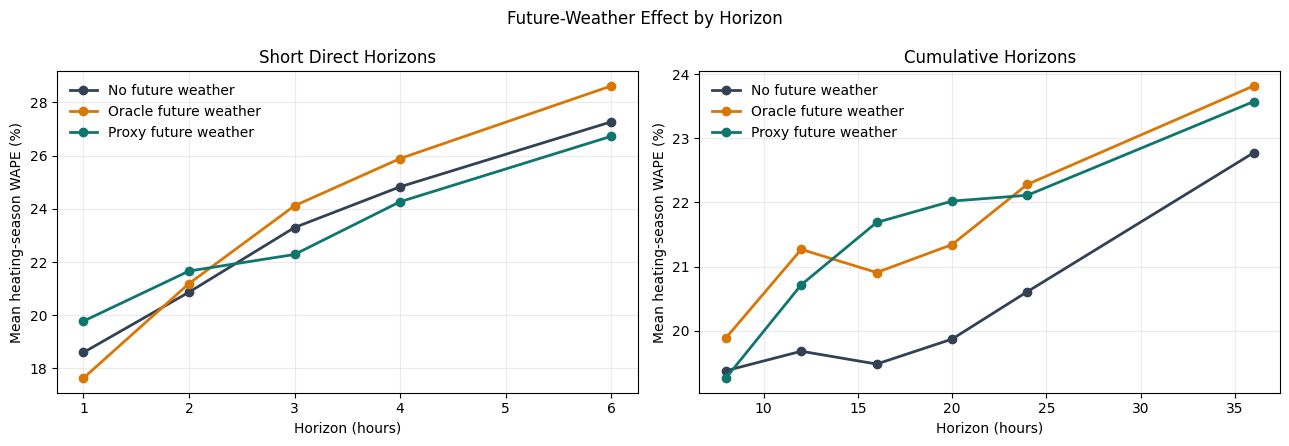

In [10]:
def load_existing_csv(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


short_run_log = load_existing_csv(SHORT_RUNLOG_FILE)
short_summary = load_existing_csv(SHORT_SUMMARY_FILE)
cumulative_run_log = load_existing_csv(CUM_RUNLOG_FILE)
cumulative_summary = load_existing_csv(CUM_SUMMARY_FILE)

combined_summary = pd.concat([
    short_summary if not short_summary.empty else pd.DataFrame(),
    cumulative_summary if not cumulative_summary.empty else pd.DataFrame(),
], ignore_index=True)

if not combined_summary.empty:
    gain_df = gain_vs_fw0(combined_summary)
    gain_df.to_csv(GAIN_FILE, index=False)
    display(gain_df.head())
else:
    gain_df = pd.DataFrame()
    print('No summary tables available yet.')


def plot_horizon_curve(summary_df: pd.DataFrame, save_path: Path = HORIZON_PLOT_FILE):
    overall = overall_summary(summary_df)
    if overall.empty:
        print('No summary data available for horizon curve yet.')
        return None
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
    mode_labels = {'FW0': 'No future weather', 'FW1': 'Oracle future weather', 'FW2': 'Proxy future weather'}
    colors = {'FW0': '#334155', 'FW1': '#d97706', 'FW2': '#0f766e'}
    for ax, task_kind, title in [
        (axes[0], 'point', 'Short Direct Horizons'),
        (axes[1], 'cumulative', 'Cumulative Horizons'),
    ]:
        part = overall.loc[overall['task_kind'] == task_kind].copy()
        if part.empty:
            ax.set_visible(False)
            continue
        for fw_mode in FUTURE_WEATHER_MODES:
            sub = part.loc[part['fw_mode'] == fw_mode].sort_values('horizon_hours')
            if sub.empty:
                continue
            ax.plot(sub['horizon_hours'], sub['mean_wape_heating_pct'], marker='o', linewidth=2, label=mode_labels[fw_mode], color=colors[fw_mode])
        ax.set_title(title)
        ax.set_xlabel('Horizon (hours)')
        ax.set_ylabel('Mean heating-season WAPE (%)')
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
    fig.suptitle('Future-Weather Effect by Horizon')
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    return fig


_ = plot_horizon_curve(combined_summary) if not combined_summary.empty else None
if HORIZON_PLOT_FILE.exists():
    display(Markdown(f'Saved horizon curve to `{HORIZON_PLOT_FILE}`'))


/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = values
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_87040/4195863103.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

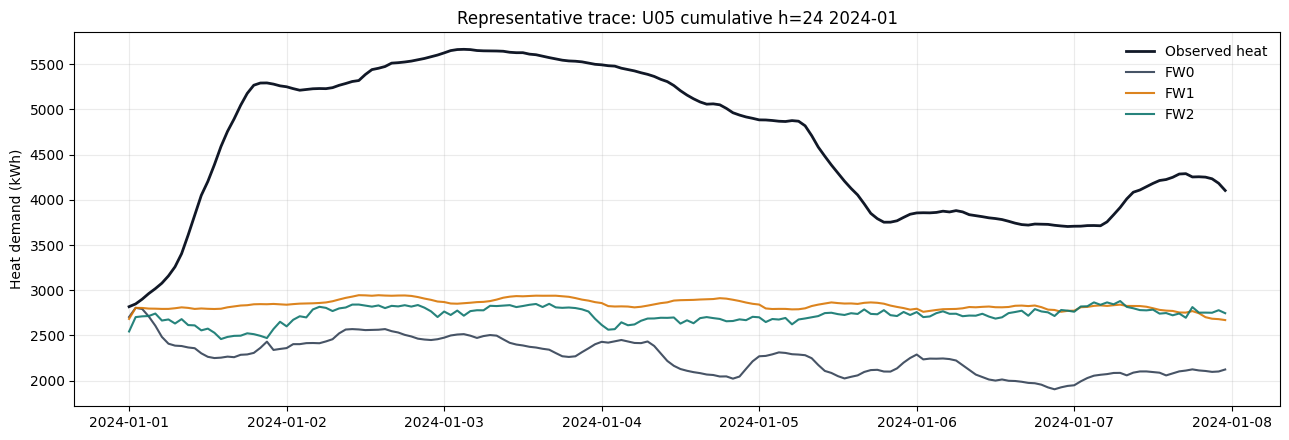

In [11]:
MAKE_TRACE_NOW = True
TRACE_CASE = {'building': 'U05', 'task_kind': 'cumulative', 'horizon_hours': 24, 'fold_id': '2024-01', 'epochs': min(EPOCHS, 12)}


def plot_trace_for_case(case: dict[str, object], save_path: Path = TRACE_PLOT_FILE):
    preds = []
    target_fold = next((fold for fold in FOLDS if fold.fold_id == case['fold_id']), None)
    if target_fold is None:
        raise KeyError(f"Fold {case['fold_id']} not found")
    for fw_mode in FUTURE_WEATHER_MODES:
        _, pred_df = run_single_case(
            building=str(case['building']),
            task_kind=str(case['task_kind']),
            horizon_hours=int(case['horizon_hours']),
            fw_mode=fw_mode,
            fold=target_fold,
            epochs=int(case['epochs']),
            return_predictions=True,
        )
        preds.append(pred_df)
    merged = None
    for pred_df in preds:
        fw_mode = pred_df['fw_mode'].iloc[0]
        sub = pred_df.loc[pred_df['is_heating']].copy()
        sub = sub[['datetime', 'y_true', 'y_pred']].rename(columns={'y_pred': f'y_pred_{fw_mode}'})
        if merged is None:
            merged = sub.rename(columns={'y_true': 'y_true'})
        else:
            merged = merged.merge(sub[['datetime', f'y_pred_{fw_mode}']], on='datetime', how='inner')
    if merged is None or merged.empty:
        print('No trace data available.')
        return None
    merged = merged.sort_values('datetime').head(7 * 24)
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(merged['datetime'], merged['y_true'], label='Observed heat', color='#111827', linewidth=2)
    ax.plot(merged['datetime'], merged['y_pred_FW0'], label='FW0', color='#334155', alpha=0.9)
    ax.plot(merged['datetime'], merged['y_pred_FW1'], label='FW1', color='#d97706', alpha=0.9)
    ax.plot(merged['datetime'], merged['y_pred_FW2'], label='FW2', color='#0f766e', alpha=0.9)
    ax.set_title(f"Representative trace: {case['building']} {case['task_kind']} h={case['horizon_hours']} {case['fold_id']}")
    ax.set_ylabel('Heat demand (kWh)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    return fig


if MAKE_TRACE_NOW:
    _ = plot_trace_for_case(TRACE_CASE)
else:
    print('Trace plot is configured but not started. Set MAKE_TRACE_NOW = True to generate it.')


## Section 9 - Thesis handoff

These draft notes are meant to be copied into the thesis later, not treated as final prose. Chapter 4 is mostly static and can already be drafted now; Chapter 6 becomes useful once at least preliminary results exist.


In [12]:
def best_mode_sentence(summary_df: pd.DataFrame, task_kind: str) -> str:
    if summary_df is None or summary_df.empty:
        return f'No {task_kind} results are available yet.'
    overall = overall_summary(summary_df)
    part = overall.loc[overall['task_kind'] == task_kind].copy()
    if part.empty:
        return f'No {task_kind} results are available yet.'
    best_rows = part.sort_values(['horizon_hours', 'mean_wape_heating_pct']).groupby('horizon_hours', as_index=False).first()
    phrases = []
    label_map = {'FW0': 'past-only anchor', 'FW1': 'oracle future weather', 'FW2': 'proxy future weather'}
    for _, row in best_rows.iterrows():
        phrases.append(f"{int(row['horizon_hours'])}h: {label_map.get(row['fw_mode'], row['fw_mode'])} ({row['mean_wape_heating_pct']:.2f} WAPE)")
    return '; '.join(phrases)


def build_ch4_note() -> str:
    return dedent(
        '''
        ### Chapter 4 insertion draft

        **Feature Exports paragraph**

        A separate future-weather block was evaluated as a small feature-engineering extension to the main temporal exports. The block was limited to future outdoor temperature and future relative humidity, because these were the most consistently justified forecast-weather variables in the related work and kept the extension methodologically narrow. For direct point horizons, the block used endpoint future weather at the forecast horizon. For cumulative horizons, it used both compact window summaries and the full per-hour future weather path across the planning window, namely future temperature mean, minimum, and end value together with future mean relative humidity plus hour-by-hour future temperature and RH features. This asymmetry was intentional: the point targets represent one future hour, while the cumulative targets represent total demand over a multi-hour window and therefore benefit from seeing the within-window weather trajectory.

        **LSTM Stage paragraph**

        A dedicated notebook-first look-ahead ablation was run to test whether forecast-like future weather improves the frozen LSTM setup without reopening architecture search. The comparison used three modes: `FW0` with no future weather, `FW1` with oracle future weather derived from realized future values, and `FW2` with a forecast-like proxy created by perturbing the oracle features with training-only uncertainty estimated from same-hour-previous-day seasonal-persistence residuals. The short-horizon diagnostic covered `U05` and `U06` at `1`, `2`, `3`, `4`, and `6` hours ahead, while the cumulative run used the six-building long-horizon subset at `8`, `12`, `16`, `20`, `24`, and `36` hours.

        **Citation note**

        Cite this paragraph with at least `\cite{WANG2020114683,RUNGE2023126661,NEUBAUER2025100480}`.
        '''
    ).strip() + '\n'


def build_ch6_note(short_summary_df: pd.DataFrame, cumulative_summary_df: pd.DataFrame) -> str:
    short_line = best_mode_sentence(short_summary_df, 'point')
    cum_line = best_mode_sentence(cumulative_summary_df, 'cumulative')
    return dedent(
        f'''
        ### Chapter 6 provisional result note

        Short-horizon future-weather diagnostic: {short_line}

        Cumulative future-weather comparison: {cum_line}

        Suggested result framing:

        - report `FW1 - FW0` as the upper-bound benefit of future weather,
        - report `FW2 - FW0` as the operationally realistic benefit,
        - report `FW1 - FW2` as the penalty from forecast uncertainty,
        - use the horizon-curve figure as the main compact visual summary,
        - keep any stronger claim centered on the cumulative horizons rather than the short-horizon diagnostic.
        '''
    ).strip() + '\n'


ch4_note = build_ch4_note()
ch6_note = build_ch6_note(short_summary, cumulative_summary)
CH4_NOTE_FILE.write_text(ch4_note, encoding='utf-8')
CH6_NOTE_FILE.write_text(ch6_note, encoding='utf-8')

display(Markdown(ch4_note))
display(Markdown(ch6_note))
print('Saved:', CH4_NOTE_FILE)
print('Saved:', CH6_NOTE_FILE)


### Chapter 4 insertion draft

**Feature Exports paragraph**

A separate future-weather block was evaluated as a small feature-engineering extension to the main temporal exports. The block was limited to future outdoor temperature and future relative humidity, because these were the most consistently justified forecast-weather variables in the related work and kept the extension methodologically narrow. For direct point horizons, the block used endpoint future weather at the forecast horizon. For cumulative horizons, it used both compact window summaries and the full per-hour future weather path across the planning window, namely future temperature mean, minimum, and end value together with future mean relative humidity plus hour-by-hour future temperature and RH features. This asymmetry was intentional: the point targets represent one future hour, while the cumulative targets represent total demand over a multi-hour window and therefore benefit from seeing the within-window weather trajectory.

**LSTM Stage paragraph**

A dedicated notebook-first look-ahead ablation was run to test whether forecast-like future weather improves the frozen LSTM setup without reopening architecture search. The comparison used three modes: `FW0` with no future weather, `FW1` with oracle future weather derived from realized future values, and `FW2` with a forecast-like proxy created by perturbing the oracle features with training-only uncertainty estimated from same-hour-previous-day seasonal-persistence residuals. The short-horizon diagnostic covered `U05` and `U06` at `1`, `2`, `3`, `4`, and `6` hours ahead, while the cumulative run used the six-building long-horizon subset at `8`, `12`, `16`, `20`, `24`, and `36` hours.

**Citation note**

Cite this paragraph with at least `\cite{WANG2020114683,RUNGE2023126661,NEUBAUER2025100480}`.


### Chapter 6 provisional result note

Short-horizon future-weather diagnostic: 1h: oracle future weather (17.63 WAPE); 2h: past-only anchor (20.87 WAPE); 3h: proxy future weather (22.28 WAPE); 4h: proxy future weather (24.27 WAPE); 6h: proxy future weather (26.73 WAPE)

Cumulative future-weather comparison: 8h: proxy future weather (19.26 WAPE); 12h: past-only anchor (19.68 WAPE); 16h: past-only anchor (19.48 WAPE); 20h: past-only anchor (19.87 WAPE); 24h: past-only anchor (20.61 WAPE); 36h: past-only anchor (22.77 WAPE)

Suggested result framing:

- report `FW1 - FW0` as the upper-bound benefit of future weather,
- report `FW2 - FW0` as the operationally realistic benefit,
- report `FW1 - FW2` as the penalty from forecast uncertainty,
- use the horizon-curve figure as the main compact visual summary,
- keep any stronger claim centered on the cumulative horizons rather than the short-horizon diagnostic.


Saved: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/future_weather_lookahead_22032026/draft_ch4_note.md
Saved: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/future_weather_lookahead_22032026/draft_ch6_note.md
